CELL 1 — MOUNT GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


CELL 2 — COPY DATASET TO COLAB LOCAL DISK

In [ ]:
# Copy from Drive to Colab local SSD — much faster for training
!cp -r "/content/drive/MyDrive/final_dataset" /content/

import os

# Verify copy
print("Verifying dataset...\n")
all_ok   = True
total    = 0
for split in ["train", "val", "test"]:
    for label in ["healthy", "diseased"]:
        folder = f"/content/final_dataset/{split}/{label}"
        count  = len(os.listdir(folder)) if os.path.exists(folder) else 0
        total += count
        status = "✓" if count > 0 else "✗  MISSING"
        if count == 0:
            all_ok = False
        print(f"  {split:5s} / {label:8s}  →  {count:>6} images  {status}")

print(f"\n  Total images : {total}")
if all_ok:
    print("✓ Dataset ready!")
else:
    print("✗ Check Drive path!")

Verifying dataset...

  train / healthy   →   11038 images  ✓
  train / diseased  →    5541 images  ✓
  val   / healthy   →    2362 images  ✓
  val   / diseased  →    1187 images  ✓
  test  / healthy   →    2364 images  ✓
  test  / diseased  →    1188 images  ✓

  Total images : 23680
✓ Dataset ready!


 CELL 3 — MIXED PRECISION  (saves GPU RAM, speeds up T4)

In [ ]:
import tensorflow as tf
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision :", tf.keras.mixed_precision.global_policy())

Mixed precision : <DTypePolicy "mixed_float16">


CELL 4 — IMPORTS

In [ ]:
import random
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, precision_score,
    recall_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow  :", tf.__version__)
print("GPU         :", tf.config.list_physical_devices('GPU'))
print("GPU RAM     : 15.0 GB  (T4)")
print("System RAM  : 12.7 GB")



TensorFlow  : 2.19.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU RAM     : 15.0 GB  (T4)
System RAM  : 12.7 GB


CELL 5 — CONFIGURATION

In [ ]:
FINAL_DIR  = "/content/final_dataset"
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/fish_project/output"

IMG_SIZE   = (160, 160)
BATCH_SIZE = 128       # safe for T4 15GB with mixed precision
SEED            = 42

PHASE1_EPOCHS = 6
PHASE1_LR       = 1e-3

PHASE2_EPOCHS   = 10
PHASE2_LR       = 1e-5
UNFREEZE_LAYERS = 30

THRESHOLD = 0.3
# prob >= THRESHOLD → HEALTHY  (class 1)
# prob <  THRESHOLD → DISEASED (class 0)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"✓ GPU : {gpus[0].name}")

print(f"\nFINAL_DIR  : {FINAL_DIR}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")
print(f"BATCH_SIZE : {BATCH_SIZE}  (T4 optimized)")
print(f"PRECISION  : mixed_float16")

✓ GPU : /physical_device:GPU:0

FINAL_DIR  : /content/final_dataset
OUTPUT_DIR : /content/drive/MyDrive/Colab Notebooks/fish_project/output
BATCH_SIZE : 128  (T4 optimized)
PRECISION  : mixed_float16


CELL 6 — DATA GENERATORS

Designed for real world phone camera conditions



In [ ]:
def build_generators():
    """
    REAL WORLD AUGMENTATION EXPLAINED:

    rotation_range=40
        Phone held at any angle — 0°, 45°, 90°, upside down

    width/height_shift=0.25
        Fish not always perfectly centered in phone frame

    zoom_range=0.35
        Fish photographed close up or from distance

    brightness_range=[0.3, 1.8]
        Early morning dim light → harsh midday sun → indoor market light

    channel_shift_range=50.0
        Wet fish reflection, different water backgrounds,
        yellowish indoor bulb light, bluish outdoor shade

    shear_range=0.15
        Phone held slightly tilted

    fill_mode="reflect"
        Better than nearest for natural looking edges when
        fish is shifted or rotated out of frame

    NO rescale — preprocess_input inside model handles this
    """

    train_aug = ImageDataGenerator(
        rotation_range      = 40,
        width_shift_range   = 0.25,
        height_shift_range  = 0.25,
        shear_range         = 0.15,
        zoom_range          = 0.35,
        horizontal_flip     = True,
        vertical_flip       = True,
        brightness_range    = [0.3, 1.8],
        channel_shift_range = 50.0,
        fill_mode           = "reflect",
        # NO rescale
    )

    eval_aug = ImageDataGenerator()   # NO rescale, NO augmentation

    common = dict(
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        seed        = SEED,
    )

    train_gen = train_aug.flow_from_directory(
        os.path.join(FINAL_DIR, "train"), shuffle=True,  **common)
    val_gen   = eval_aug.flow_from_directory(
        os.path.join(FINAL_DIR, "val"),   shuffle=False, **common)
    test_gen  = eval_aug.flow_from_directory(
        os.path.join(FINAL_DIR, "test"),  shuffle=False, **common)

    print(f"\n  Class indices : {train_gen.class_indices}")
    print(f"  Train images  : {train_gen.samples}")
    print(f"  Val   images  : {val_gen.samples}")
    print(f"  Test  images  : {test_gen.samples}")
    print(f"  Batches/epoch : {len(train_gen)}")
    return train_gen, val_gen, test_gen


train_gen, val_gen, test_gen = build_generators()


Found 16572 images belonging to 2 classes.
Found 3548 images belonging to 2 classes.
Found 3551 images belonging to 2 classes.

  Class indices : {'diseased': 0, 'healthy': 1}
  Train images  : 16572
  Val   images  : 3548
  Test  images  : 3551
  Batches/epoch : 130


CELL 7 — CLASS WEIGHTS  (handles 2:1 healthy:diseased imbalance)

In [ ]:
def get_class_weights(train_gen):
    labels  = train_gen.classes
    classes = np.unique(labels)
    weights = compute_class_weight("balanced", classes=classes, y=labels)
    cw      = dict(zip(classes.tolist(), weights.tolist()))

    idx_to_label = {v: k for k, v in train_gen.class_indices.items()}
    print("\n  Class weights (balances the 2:1 healthy:diseased ratio):")
    for idx, w in cw.items():
        print(f"    {idx_to_label[idx]:10s} (class {idx})  →  weight = {w:.4f}")
    return cw

class_weights = get_class_weights(train_gen)


  Class weights (balances the 2:1 healthy:diseased ratio):
    diseased   (class 0)  →  weight = 1.4973
    healthy    (class 1)  →  weight = 0.7507


CELL 8 — BUILD MODEL

In [ ]:
def build_model():
    """
    EfficientNetB0 — chosen because:
      1. Already achieved AUC 0.995 on previous smaller dataset
      2. Fits in T4 15GB with batch_size=64 + mixed precision
      3. Training completes within 5hr Colab session
      4. Lightweight enough for fast prediction on laptop CPU

    Architecture changes for real world use:
      - Larger dropout (0.50 / 0.30) prevents overfitting on varied backgrounds
      - L2 regularization keeps weights from memorizing specific backgrounds
      - float32 output layer prevents mixed precision numerical issues
      - preprocess_input as first layer — critical, handles raw phone photos
    """

    base = EfficientNetB0(
        weights     = "imagenet",
        include_top = False,
        input_shape = (*IMG_SIZE, 3),
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))

    # ── CRITICAL: preprocessing INSIDE model ───────────────────────────────
    # Raw pixels [0,255] from phone camera go in
    # preprocess_input scales to [-1,1] for EfficientNet
    # DO NOT rescale outside — this was the bug that caused AUC=0.50
    x = layers.Lambda(
        lambda img: preprocess_input(img),
        name="efficientnet_preprocessing"
    )(inputs)

    x = base(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    # Dense block 1 — larger dropout for real world generalization
    x = layers.Dense(
        256, activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.50)(x)   # 0.50 vs 0.45 — more regularization

    # Dense block 2
    x = layers.Dense(
        64, activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.30)(x)   # 0.30 vs 0.25 — more regularization

    # Output — float32 cast for mixed precision stability
    x       = layers.Dense(1)(x)
    outputs = layers.Activation("sigmoid", dtype="float32", name="output")(x)

    model = Model(inputs, outputs, name="FishDiseaseDetector_RealWorld")

    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=PHASE1_LR),
        loss      = "binary_crossentropy",
        metrics   = [
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    total     = model.count_params()
    trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"\n  Model         : EfficientNetB0 (real world optimized)")
    print(f"  Total params  : {total:,}")
    print(f"  Trainable     : {trainable:,}  (head only — base frozen)")
    print(f"  Dropout       : 0.50 / 0.30  (higher for real world)")
    print(f"  Precision     : mixed_float16")
    return model, base

model, base = build_model()
model.summary()



  Model         : EfficientNetB0 (real world optimized)
  Total params  : 4,399,140
  Trainable     : 347,009  (head only — base frozen)
  Dropout       : 0.50 / 0.30  (higher for real world)
  Precision     : mixed_float16


Model: "FishDiseaseDetector_RealWorld"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_preprocessing      │ (None, 160, 160, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Activation)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 347,009 (1.32 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

CELL 9 — CALLBACKSCELL 9 — ADD BLUR AUGMENTATION  (simulates phone camera blur)  

In [ ]:
"""
ImageDataGenerator cannot do blur.
This cell wraps the generators in tf.data pipelines
and adds random Gaussian blur to 30% of training images.

Why blur matters:
  - Phone cameras blur when fish is moving
  - User's hand is not steady
  - Fish in water creates motion blur
  - WhatsApp compresses and slightly blurs images
"""

def apply_blur(image, label):
    """Apply random blur to simulate phone camera conditions."""
    # Blur 30% of images
    apply = tf.random.uniform(()) < 0.3
    if apply:
        # Gaussian blur using depthwise conv
        kernel_size = tf.random.uniform((), minval=1, maxval=3,
                                        dtype=tf.int32) * 2 + 1
        image = tf.cast(image, tf.float32)
        image = tf.expand_dims(image, 0)
        # Average pool as approximation of blur
        image = tf.nn.avg_pool2d(
            image,
            ksize   = [1, 3, 3, 1],
            strides = [1, 1, 1, 1],
            padding = "SAME"
        )
        image = tf.squeeze(image, 0)
    return image, label


def make_tf_dataset(generator, apply_augmentation=False):
    """Wrap ImageDataGenerator in tf.data for blur + prefetch."""
    dataset = tf.data.Dataset.from_generator(
        lambda: generator,
        output_signature=(
            tf.TensorSpec(shape=(None, *IMG_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None,),              dtype=tf.float32),
        )
    )
    if apply_augmentation:
        dataset = dataset.map(
            lambda x, y: tf.map_fn(
                lambda img_y: apply_blur(img_y[0], img_y[1]),
                (x, y),
                fn_output_signature=(
                    tf.TensorSpec(shape=(*IMG_SIZE, 3), dtype=tf.float32),
                    tf.TensorSpec(shape=(),             dtype=tf.float32),
                )
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    # Prefetch for faster training
    return dataset.prefetch(tf.data.AUTOTUNE)


train_dataset = make_tf_dataset(train_gen, apply_augmentation=True)
val_dataset   = make_tf_dataset(val_gen,   apply_augmentation=False)

print("✓ Blur augmentation applied to training data (30% of images)")
print("✓ Prefetch enabled for fast data loading on T4")


✓ Blur augmentation applied to training data (30% of images)
✓ Prefetch enabled for fast data loading on T4


CELL 10 — CALLBACKS  

In [ ]:
def get_callbacks(phase_name):
    return [
        ModelCheckpoint(
            filepath       = os.path.join(MODEL_DIR, "best_model.keras"),
            monitor        = "val_auc",
            mode           = "max",
            save_best_only = True,
            verbose        = 1,
        ),
        EarlyStopping(
            monitor              = "val_auc",
            mode                 = "max",
            patience             = 3,
            restore_best_weights = True,
            verbose              = 1,
        ),
        ReduceLROnPlateau(
            monitor  = "val_loss",
            factor   = 0.5,
            patience = 3,
            min_lr   = 1e-8,
            verbose  = 1,
        ),
        CSVLogger(
            os.path.join(MODEL_DIR, f"log_{phase_name}.csv"),
            append=True
        ),
    ]


 CELL 11 — PHASE 1: HEAD ONLY TRAINING

In [ ]:
print("\n" + "="*60)
print("  PHASE 1 — Head training  (base frozen)")
print("  Expected: accuracy > 0.75 by epoch 3-5")
print("="*60 + "\n")

history1 = model.fit(
    train_dataset,
    validation_data  = val_dataset,
    epochs           = PHASE1_EPOCHS,
    steps_per_epoch  = len(train_gen),
    validation_steps = len(val_gen),
    class_weight     = class_weights,
    callbacks        = get_callbacks("phase1"),
    verbose          = 1,
)



  PHASE 1 — Head training  (base frozen)
  Expected: accuracy > 0.75 by epoch 3-5

Epoch 1/6
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8030 - auc: 0.8831 - loss: 0.4917 - precision: 0.8937 - recall: 0.7994
Epoch 1: val_auc improved from None to 0.97797, saving model to /content/drive/MyDrive/Colab Notebooks/fish_project/output/models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/fish_project/output/models/best_model.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 616s 4s/step - accuracy: 0.8523 - auc: 0.9320 - loss: 0.3895 - precision: 0.9284 - recall: 0.8434 - val_accuracy: 0.9183 - val_auc: 0.9780 - val_loss: 0.2574 - val_precision: 0.9485 - val_recall: 0.9276 - learning_rate: 0.0010
Epoch 2/6
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8952 - auc: 0.9630 - loss: 0.2964 - precision: 0.9621 - recall: 0.8759
Epoch 2: val_auc improved from 0.97797 to 0.98632, saving model to /content/drive/MyDrive/Colab Notebooks/fish_project/output

 CELL 12 — PHASE 2: FINE-TUNE TOP LAYERS

In [ ]:
print("\n" + "="*60)
print(f"  PHASE 2 — Fine-tuning top {UNFREEZE_LAYERS} layers")
print("  Expected: accuracy 0.92 - 0.97+")
print("="*60 + "\n")

base.trainable = True
for layer in base.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=PHASE2_LR),
    loss      = "binary_crossentropy",
    metrics   = [
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"  Trainable params after unfreezing : {trainable:,}\n")

history2 = model.fit(
    train_dataset,
    validation_data  = val_dataset,
    epochs           = PHASE2_EPOCHS,
    steps_per_epoch  = len(train_gen),
    validation_steps = len(val_gen),
    class_weight     = class_weights,
    callbacks        = get_callbacks("phase2"),
    verbose          = 1,
)


  PHASE 2 — Fine-tuning top 30 layers
  Expected: accuracy 0.92 - 0.97+

  Trainable params after unfreezing : 1,843,169

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8874 - auc: 0.9607 - loss: 0.3065 - precision: 0.9541 - recall: 0.8726
Epoch 1: val_auc improved from None to 0.99110, saving model to /content/drive/MyDrive/Colab Notebooks/fish_project/output/models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/fish_project/output/models/best_model.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 548s 4s/step - accuracy: 0.8921 - auc: 0.9644 - loss: 0.2941 - precision: 0.9596 - recall: 0.8746 - val_accuracy: 0.9549 - val_auc: 0.9911 - val_loss: 0.1741 - val_precision: 0.9766 - val_recall: 0.9551 - learning_rate: 1.0000e-05
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8975 - auc: 0.9720 - loss: 0.2678 - precision: 0.9650 - recall: 0.8775
Epoch 2: val_auc did not improve from 0.99110
130/130 ━━━━━━━━━━━━━━━━━━━━ 371s 

CELL 13 — TRAINING HISTORY PLOTS

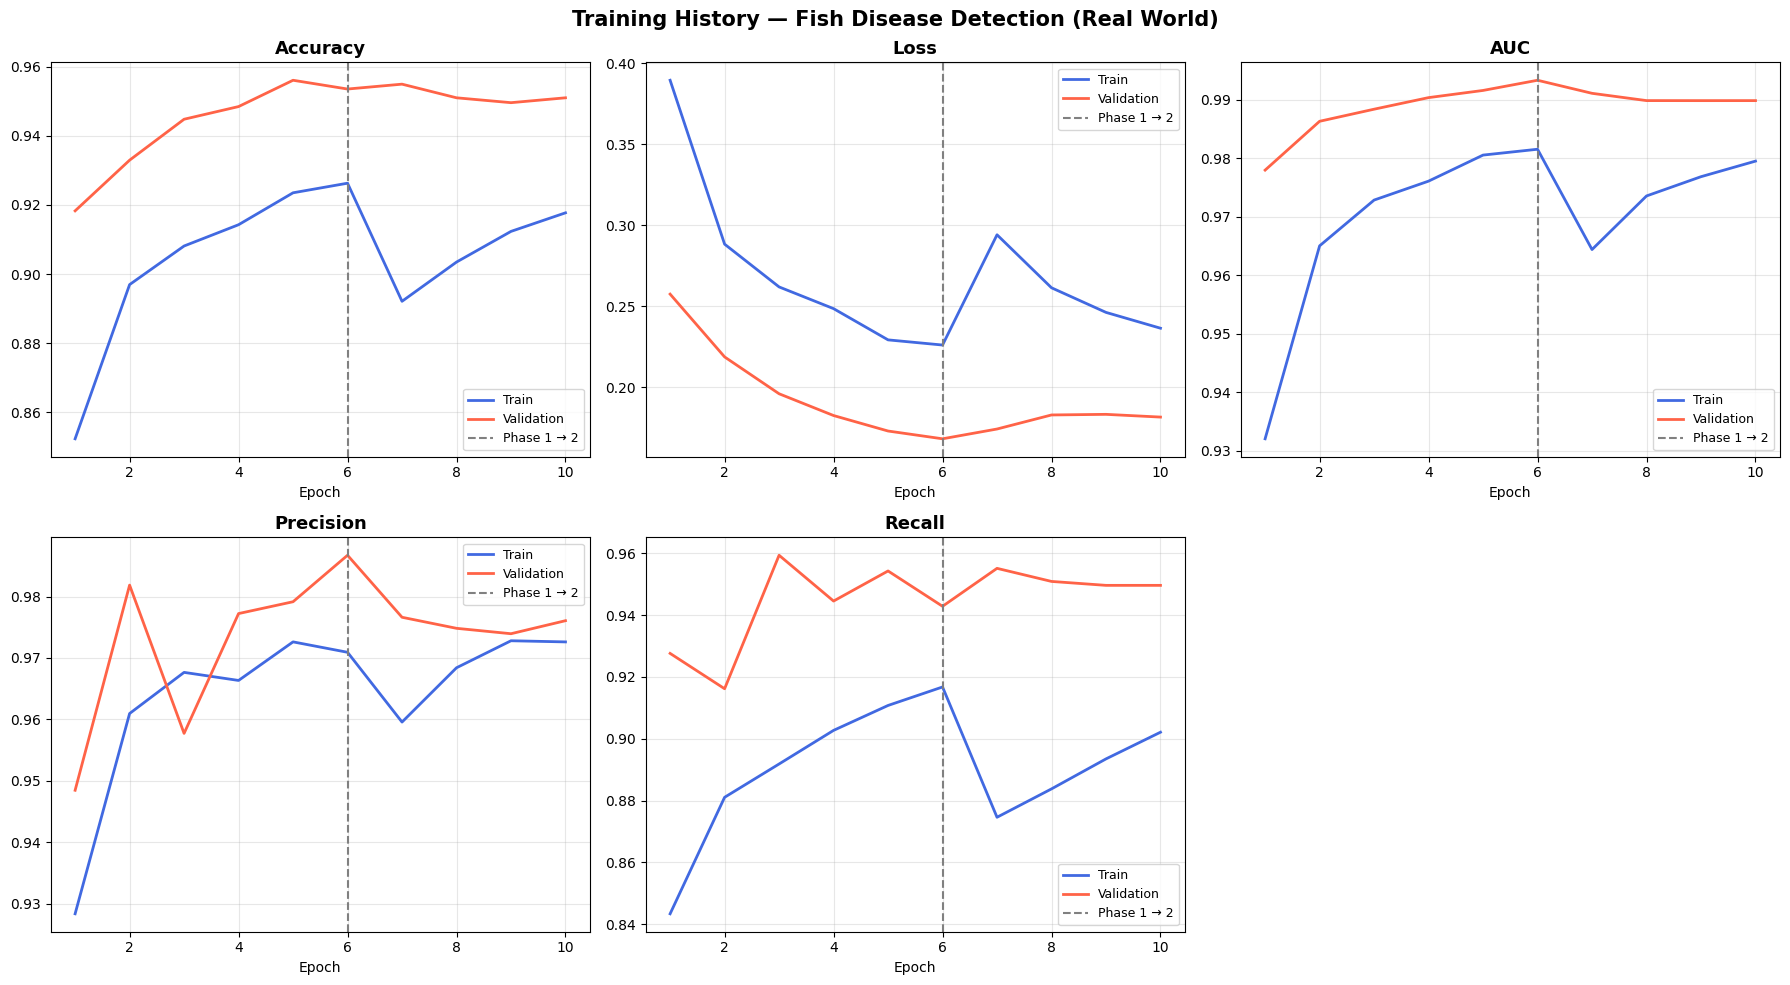

Saved → /content/drive/MyDrive/Colab Notebooks/fish_project/output/plots/training_history.png


In [ ]:
def merge(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

metrics_to_plot = [
    ("accuracy",  "val_accuracy",  "Accuracy"),
    ("loss",      "val_loss",      "Loss"),
    ("auc",       "val_auc",       "AUC"),
    ("precision", "val_precision", "Precision"),
    ("recall",    "val_recall",    "Recall"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
phase1_end = len(history1.history.get("accuracy", []))

for i, (train_key, val_key, title) in enumerate(metrics_to_plot):
    train_vals = merge(history1, history2, train_key)
    val_vals   = merge(history1, history2, val_key)
    ep         = range(1, len(train_vals) + 1)
    axes[i].plot(ep, train_vals, label="Train",      color="royalblue", lw=2)
    axes[i].plot(ep, val_vals,   label="Validation", color="tomato",    lw=2)
    axes[i].axvline(x=phase1_end, color="gray", linestyle="--",
                    linewidth=1.5, label="Phase 1 → 2")
    axes[i].set_title(title, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Epoch")
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

axes[5].axis("off")
plt.suptitle("Training History — Fish Disease Detection (Real World)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
hist_path = os.path.join(PLOTS_DIR, "training_history.png")
plt.savefig(hist_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {hist_path}")

 CELL 14 — SAVE MODEL AS SAVEDMODEL FORMAT                              This is the ONLY format that works correctly for offline prediction

In [ ]:
print("\n" + "="*60)
print("  SAVING MODEL")
print("="*60 + "\n")

# ── SavedModel — version independent, works on any machine ────────────────
saved_model_path = os.path.join(MODEL_DIR, "saved_model")

# Remove old if exists
if os.path.exists(saved_model_path):
    shutil.rmtree(saved_model_path)

model.export(saved_model_path)
print(f"  ✓ SavedModel exported  → {saved_model_path}")

# ── Zip for easy download ──────────────────────────────────────────────────
zip_path = os.path.join(MODEL_DIR, "saved_model")
shutil.make_archive(zip_path, "zip", MODEL_DIR, "saved_model")
print(f"  ✓ Zipped               → {zip_path}.zip")
print(f"\n  ← Download saved_model.zip from Drive")

print(f"""
  ════════════════════════════════════════════════════════
  OFFLINE SETUP:
    1. Download  →  saved_model.zip
    2. Extract   →  fish_disease_project/output/models/saved_model/
    3. Update THRESHOLD in predict.py to : (optimal_thr will be available after evaluation)
    4. Run       →  python predict.py
  ════════════════════════════════════════════════════════
""")


  SAVING MODEL

Saved artifact at '/content/drive/MyDrive/Colab Notebooks/fish_project/output/models/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_493')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140541230324176: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  140541230325136: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  140541276399824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276398480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276400400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276401360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276401936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276397712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276400592: TensorSpec(shape=(), dtype=tf.resourc

CELL 14 — EVALUATE ON TEST SET


  EVALUATING ON TEST SET

28/28 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step

  Accuracy  : 0.9611
  Precision : 0.9282  (diseased class)
  Recall    : 0.9579  (diseased class)
  F1 Score  : 0.9428  (diseased class)
  ROC-AUC   : 0.9932

  Classification Report:
              precision    recall  f1-score   support

    diseased       0.93      0.96      0.94      1187
     healthy       0.98      0.96      0.97      2364

    accuracy                           0.96      3551
   macro avg       0.95      0.96      0.96      3551
weighted avg       0.96      0.96      0.96      3551

Saved → /content/drive/MyDrive/Colab Notebooks/fish_project/output/evaluation_report.txt


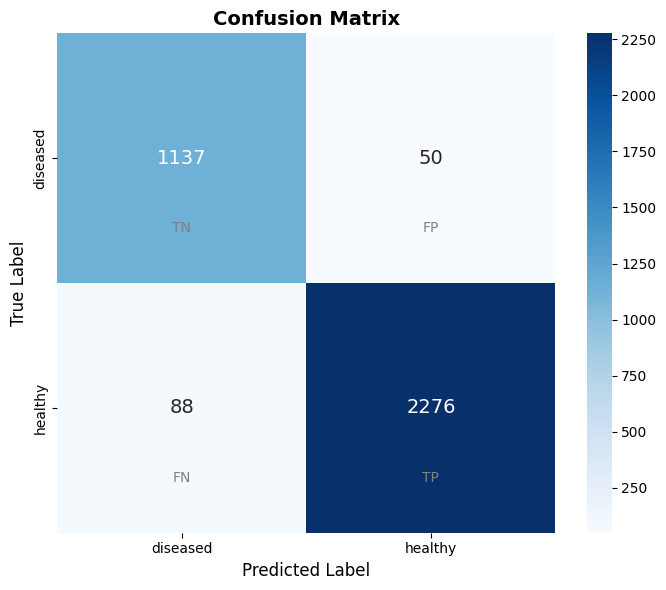

Saved → /content/drive/MyDrive/Colab Notebooks/fish_project/output/plots/confusion_matrix.png


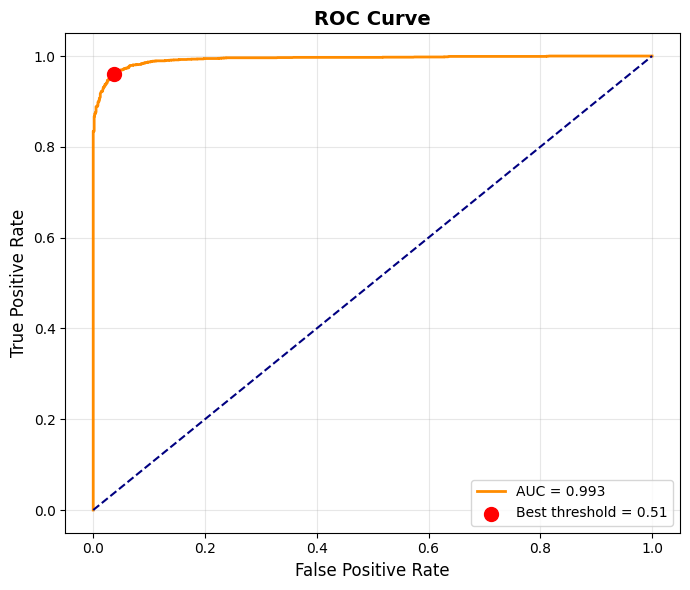

Saved → /content/drive/MyDrive/Colab Notebooks/fish_project/output/plots/roc_curve.png

  Best threshold from ROC : 0.5080
  ← Use this as THRESHOLD in predict.py


In [ ]:
print("\n" + "="*60)
print("  EVALUATING ON TEST SET")
print("="*60 + "\n")

test_gen.reset()
y_prob = model.predict(test_gen, verbose=1).flatten()

# CORRECT: >= THRESHOLD = HEALTHY (class 1)
y_pred = (y_prob >= THRESHOLD).astype(int)
y_true = test_gen.classes

class_names  = list(test_gen.class_indices.keys())
diseased_idx = test_gen.class_indices["diseased"]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label=diseased_idx)
rec  = recall_score(y_true, y_pred,    pos_label=diseased_idx)
f1   = f1_score(y_true, y_pred,        pos_label=diseased_idx)
auc  = roc_auc_score(y_true, y_prob)

print(f"\n  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}  (diseased class)")
print(f"  Recall    : {rec:.4f}  (diseased class)")
print(f"  F1 Score  : {f1:.4f}  (diseased class)")
print(f"  ROC-AUC   : {auc:.4f}")

print("\n  Classification Report:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Save report
report_path = os.path.join(OUTPUT_DIR, "evaluation_report.txt")
with open(report_path, "w") as f:
    f.write("FISH DISEASE DETECTION — EVALUATION REPORT\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Accuracy  : {acc:.4f}\n")
    f.write(f"Precision : {prec:.4f}\n")
    f.write(f"Recall    : {rec:.4f}\n")
    f.write(f"F1 Score  : {f1:.4f}\n")
    f.write(f"ROC-AUC   : {auc:.4f}\n\n")
    f.write(report)
print(f"Saved → {report_path}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
label_map = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        plt.text(j + 0.5, i + 0.78, label_map[i][j],
                 ha="center", va="center", fontsize=10, color="gray")
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.ylabel("True Label",      fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
cm_path = os.path.join(PLOTS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved → {cm_path}")

# ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_thr = float(thresholds_roc[optimal_idx])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color="red",
            zorder=5, s=100, label=f"Best threshold = {optimal_thr:.2f}")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate",  fontsize=12)
plt.title("ROC Curve",            fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(PLOTS_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=150)
plt.show()
print(f"Saved → {roc_path}")
print(f"\n  Best threshold from ROC : {optimal_thr:.4f}")
print(f"  ← Use this as THRESHOLD in predict.py")

CELL 15 — SAVE AS SAVEDMODEL (only format that works offline)   

In [ ]:
print("\n" + "="*60)
print("  SAVING MODEL")
print("="*60 + "\n")

saved_model_path = os.path.join(MODEL_DIR, "saved_model")

if os.path.exists(saved_model_path):
    shutil.rmtree(saved_model_path)

model.export(saved_model_path)
print(f"  ✓ SavedModel exported → {saved_model_path}")

zip_path = os.path.join(MODEL_DIR, "saved_model")
shutil.make_archive(zip_path, "zip", MODEL_DIR, "saved_model")
print(f"  ✓ Zipped             → {zip_path}.zip")
print(f"\n  ← Download saved_model.zip from Drive")

print(f"""
  ════════════════════════════════════════════════════════
  OFFLINE SETUP:
    1. Download  saved_model.zip from Drive
    2. Extract   to fish_disease_project/output/models/saved_model/
    3. Update    THRESHOLD in predict.py to : {optimal_thr:.2f}
    4. Run       python predict.py
  ════════════════════════════════════════════════════════
""")



  SAVING MODEL

Saved artifact at '/content/drive/MyDrive/Colab Notebooks/fish_project/output/models/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_493')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140541230324176: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  140541230325136: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  140541276399824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276398480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276400400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276401360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276401936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276397712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140541276400592: TensorSpec(shape=(), dtype=tf.resourc

CELL 16 — TEST SINGLE IMAGE IN COLAB  

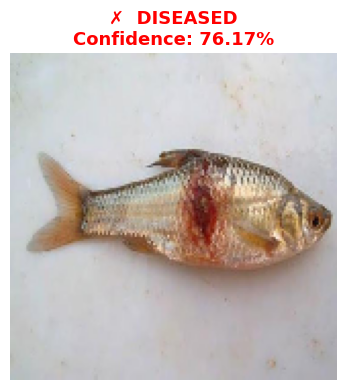


  Result     : ✗ DISEASED
  Confidence : 76.17%
  Raw prob   : 0.2383  (>= 0.3 = HEALTHY)


('DISEASED', 0.23828421533107758)

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image_colab(image_path):
    """
    Test any single fish image in Colab after training.

    Usage:
        predict_image_colab("/content/drive/MyDrive/Colab Notebooks/fish1.jpg")

    Works with:
        - Phone camera photos
        - WhatsApp images
        - Any resolution (auto-resized to 224x224)
    """
    # Raw pixels [0,255] — NO rescaling — preprocessing inside model
    img  = keras_image.load_img(image_path, target_size=IMG_SIZE)
    arr  = keras_image.img_to_array(img)
    arr  = np.expand_dims(arr, axis=0)

    prob  = float(model.predict(arr, verbose=0)[0][0])
    label = "HEALTHY"  if prob >= THRESHOLD else "DISEASED"
    conf  = prob       if prob >= THRESHOLD else 1.0 - prob
    icon  = "✓"        if label == "HEALTHY" else "✗"
    color = "green"    if label == "HEALTHY" else "red"

    plt.figure(figsize=(4, 4))
    plt.imshow(keras_image.load_img(image_path, target_size=IMG_SIZE))
    plt.title(f"{icon}  {label}\nConfidence: {conf:.2%}",
              fontsize=13, fontweight="bold", color=color)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"\n  Result     : {icon} {label}")
    print(f"  Confidence : {conf:.2%}")
    print(f"  Raw prob   : {prob:.4f}  (>= {THRESHOLD} = HEALTHY)")
    return label, prob

# ── Change path and run this cell to test any fish image ─────────────────
predict_image_colab("/content/WhatsApp Image 2026-03-23 at 7.49.55 PM.jpeg")

CELL 17 — FINAL SUMMARY

In [ ]:
print("\n" + "="*60)
print("  TRAINING COMPLETE")
print("="*60)
print(f"""
  Hardware
  ─────────────────────────────────────────
  GPU          :  T4  (15 GB)
  System RAM   :  12.7 GB
  Precision    :  mixed_float16
  Batch size   :  {BATCH_SIZE}

  Real World Optimizations Applied
  ─────────────────────────────────────────
  ✓ Phone angle variation     (rotation 40°)
  ✓ Off-center fish           (shift 25%)
  ✓ Close/far camera          (zoom 35%)
  ✓ Daylight to dark market   (brightness 0.3-1.8)
  ✓ Wet fish glare            (channel shift 50)
  ✓ Phone camera blur         (30% of images)
  ✓ Reflection fill           (fill_mode=reflect)
  ✓ Higher dropout            (0.50 / 0.30)

  Dataset
  ─────────────────────────────────────────
  Train        :  {train_gen.samples}  images
  Val          :  {val_gen.samples}    images
  Test         :  {test_gen.samples}   images

  Test Results
  ─────────────────────────────────────────
  Accuracy     :  {acc:.4f}
  Precision    :  {prec:.4f}
  Recall       :  {rec:.4f}
  F1 Score     :  {f1:.4f}
  ROC-AUC      :  {auc:.4f}

  Best threshold (ROC) : {optimal_thr:.4f}
  ← Update in predict.py

  Files on Google Drive
  ─────────────────────────────────────────
  saved_model.zip  → {zip_path}.zip  ← DOWNLOAD
  best_model.keras → {os.path.join(MODEL_DIR, 'best_model.keras')}
  eval report      → {report_path}
  Plots            → {PLOTS_DIR}/
""")
